In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import librosa


In [3]:
DATA_ROOT = Path("../data/ODAQ")

RESULTS_PATH = (
    DATA_ROOT
    / "ODAQ_listening_test"
    / "ODAQ_results.csv"
)

AUDIO_ROOT = (
    DATA_ROOT
    / "ODAQ_listening_test"
)

In [4]:
results = pd.read_csv(
    RESULTS_PATH,
    sep=None,
    engine="python"
)

print(results.shape)
results.head()

(6240, 6)


,score,method,condition,process,item,subject
0,47.0,LP,LP3.5,LP35,LP_11_guitar,Subject 1: USLA08
1,5.0,LP,LP3.5,LP35,LP_11_guitar,Subject 2: DEID44
2,10.0,LP,LP3.5,LP35,LP_11_guitar,Subject 3: DEID1115
3,20.0,LP,LP3.5,LP35,LP_11_guitar,Subject 4: DEID337
4,30.0,LP,LP3.5,LP35,LP_11_guitar,Subject 5: USLA06


In [5]:
scores_df = (
    results
    .groupby(
        ["item", "condition", "method", "process"],
        as_index=False
    )
    .agg(
        score_mean=("score", "mean"),
        score_std=("score", "std"),
        score_median=("score", "median"),
        n_ratings=("score", "count")
    )
)

print(scores_df.shape)
scores_df.head()

(240, 8)


,item,condition,method,process,score_mean,score_std,score_median,n_ratings
0,DE_CosmosLandromat_remix1_LD6,LP3.5,DE,LP35,19.230769,11.772197,20.0,26
1,DE_CosmosLandromat_remix1_LD6,LP7,DE,LP70,44.153846,21.528943,40.5,26
2,DE_CosmosLandromat_remix1_LD6,Q1,DE,OpenUnmix_mid,18.346154,9.616412,16.0,26
3,DE_CosmosLandromat_remix1_LD6,Q2,DE,TFC_TDF_U_Net_mid,26.769231,15.092535,22.0,26
4,DE_CosmosLandromat_remix1_LD6,Q3,DE,Cocktail_mid,42.576923,22.409236,39.0,26


In [6]:
scores_df["audio_path"] = scores_df.apply(
    lambda row:
        AUDIO_ROOT
        / row["item"]
        / f"{row['process']}.wav",
    axis=1
)


In [7]:
scores_df["file_exists"] = (
    scores_df["audio_path"]
    .apply(lambda path: path.exists())
)

print(
    "Files found:",
    scores_df["file_exists"].sum()
)

print(
    "Files missing:",
    (~scores_df["file_exists"]).sum()
)

Files found: 240
Files missing: 0


In [8]:
TARGET_SR = 44100
N_FFT = 2048
HOP_LENGTH = 512
N_MFCC = 13

In [9]:
def extract_audio_features(
    file_path,
    target_sr=TARGET_SR,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mfcc=N_MFCC
):

    # ---------------------------
    # Load audio
    # ---------------------------
    y, sr = librosa.load(
        file_path,
        sr=target_sr,
        mono=True
    )

    features = {}

    # ---------------------------
    # RMS Energy
    # ---------------------------
    rms = librosa.feature.rms(
        y=y,
        frame_length=n_fft,
        hop_length=hop_length
    )

    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    # ---------------------------
    # Zero Crossing Rate
    # ---------------------------
    zcr = librosa.feature.zero_crossing_rate(
        y,
        frame_length=n_fft,
        hop_length=hop_length
    )

    features["zcr_mean"] = np.mean(zcr)
    features["zcr_std"] = np.std(zcr)

    # ---------------------------
    # Spectral Centroid
    # ---------------------------
    centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length
    )

    features["centroid_mean"] = np.mean(centroid)
    features["centroid_std"] = np.std(centroid)

    # ---------------------------
    # Spectral Bandwidth
    # ---------------------------
    bandwidth = librosa.feature.spectral_bandwidth(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length
    )

    features["bandwidth_mean"] = np.mean(bandwidth)
    features["bandwidth_std"] = np.std(bandwidth)

    # ---------------------------
    # Spectral Rolloff
    # ---------------------------
    rolloff = librosa.feature.spectral_rolloff(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        roll_percent=0.85
    )

    features["rolloff_mean"] = np.mean(rolloff)
    features["rolloff_std"] = np.std(rolloff)

    # ---------------------------
    # MFCC
    # ---------------------------
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length
    )

    mfcc_mean = np.mean(
        mfcc,
        axis=1
    )

    mfcc_std = np.std(
        mfcc,
        axis=1
    )

    for i in range(n_mfcc):

        features[f"mfcc_{i+1}_mean"] = (
            mfcc_mean[i]
        )

        features[f"mfcc_{i+1}_std"] = (
            mfcc_std[i]
        )

    return features

In [10]:
test_path = scores_df.iloc[0]["audio_path"]

print(test_path)

..\data\ODAQ\ODAQ_listening_test\DE_CosmosLandromat_remix1_LD6\LP35.wav


In [12]:
test_features = extract_audio_features(
    test_path
)

test_features

{'rms_mean': np.float32(0.031402417),
 'rms_std': np.float32(0.03570158),
 'zcr_mean': np.float64(0.03749966012906032),
 'zcr_std': np.float64(0.0342177410853484),
 'centroid_mean': np.float64(974.7619730246498),
 'centroid_std': np.float64(543.516470217315),
 'bandwidth_mean': np.float64(810.7489349248821),
 'bandwidth_std': np.float64(232.39434763655257),
 'rolloff_mean': np.float64(1804.392492024362),
 'rolloff_std': np.float64(822.1442303163295),
 'mfcc_1_mean': np.float32(-419.53317),
 'mfcc_1_std': np.float32(49.546535),
 'mfcc_2_mean': np.float32(159.60336),
 'mfcc_2_std': np.float32(41.762142),
 'mfcc_3_mean': np.float32(17.27441),
 'mfcc_3_std': np.float32(31.691988),
 'mfcc_4_mean': np.float32(-13.139897),
 'mfcc_4_std': np.float32(21.501616),
 'mfcc_5_mean': np.float32(28.646458),
 'mfcc_5_std': np.float32(22.054829),
 'mfcc_6_mean': np.float32(26.486025),
 'mfcc_6_std': np.float32(14.928329),
 'mfcc_7_mean': np.float32(-6.376355),
 'mfcc_7_std': np.float32(16.170547),
 'mfc

In [13]:
print(
    "Number of extracted features:",
    len(test_features)
)

Number of extracted features: 36


In [14]:
list(test_features.items())[:10]

[('rms_mean', np.float32(0.031402417)),
 ('rms_std', np.float32(0.03570158)),
 ('zcr_mean', np.float64(0.03749966012906032)),
 ('zcr_std', np.float64(0.0342177410853484)),
 ('centroid_mean', np.float64(974.7619730246498)),
 ('centroid_std', np.float64(543.516470217315)),
 ('bandwidth_mean', np.float64(810.7489349248821)),
 ('bandwidth_std', np.float64(232.39434763655257)),
 ('rolloff_mean', np.float64(1804.392492024362)),
 ('rolloff_std', np.float64(822.1442303163295))]

In [15]:
print(len(test_features))


36


In [16]:
from tqdm.auto import tqdm

In [17]:
feature_rows = []

for _, row in tqdm(
    scores_df.iterrows(),
    total=len(scores_df),
    desc="Extracting audio features"
):

    features = extract_audio_features(
        row["audio_path"]
    )

    # Metadata
    features["item"] = row["item"]
    features["condition"] = row["condition"]
    features["method"] = row["method"]
    features["process"] = row["process"]

    # Targets / human-rating information
    features["score_mean"] = row["score_mean"]
    features["score_std"] = row["score_std"]
    features["score_median"] = row["score_median"]
    features["n_ratings"] = row["n_ratings"]

    feature_rows.append(features)

Extracting audio features:   0%|          | 0/240 [00:00<?, ?it/s]

In [18]:
features_df = pd.DataFrame(feature_rows)

print("Shape:", features_df.shape)

display(features_df.head())

Shape: (240, 44)


,rms_mean,rms_std,zcr_mean,zcr_std,centroid_mean,centroid_std,bandwidth_mean,bandwidth_std,rolloff_mean,rolloff_std,...,mfcc_13_mean,mfcc_13_std,item,condition,method,process,score_mean,score_std,score_median,n_ratings
0,0.031402,0.035702,0.037500,0.034218,974.761973,543.516470,810.748935,232.394348,1804.392492,822.144230,...,2.051651,9.129880,DE_CosmosLandromat_remix1_LD6,LP3.5,DE,LP35,19.230769,11.772197,20.0,26
1,0.032454,0.035265,0.053428,0.059231,1602.597174,1083.385344,1473.561877,348.874161,2920.521860,1707.200039,...,-0.259503,9.164764,DE_CosmosLandromat_remix1_LD6,LP7,DE,LP70,44.153846,21.528943,40.5,26
2,0.034160,0.033339,0.066034,0.074404,2362.891636,1554.666661,2695.249999,731.598696,4242.365762,2712.605690,...,-2.673537,6.828379,DE_CosmosLandromat_remix1_LD6,Q1,DE,OpenUnmix_mid,18.346154,9.616412,16.0,26
3,0.034937,0.033483,0.058914,0.077742,2453.770404,1750.814452,3128.944566,920.300337,4623.068797,3333.164288,...,1.487528,7.693702,DE_CosmosLandromat_remix1_LD6,Q2,DE,TFC_TDF_U_Net_mid,26.769231,15.092535,22.0,26
4,0.029821,0.035545,0.055902,0.065832,2535.865324,1661.842621,3345.480041,958.711958,4767.331265,3343.154888,...,-3.328748,8.267073,DE_CosmosLandromat_remix1_LD6,Q3,DE,Cocktail_mid,42.576923,22.409236,39.0,26


In [19]:
print("Missing values:")
print(features_df.isna().sum().sum())

numeric_df = features_df.select_dtypes(
    include=np.number
)

print(
    "Infinite values:",
    np.isinf(numeric_df).sum().sum()
)

print(
    "Duplicated rows:",
    features_df.duplicated().sum()
)

Missing values:
0
Infinite values: 0
Duplicated rows: 0


In [20]:
features_df[
    [
        "item",
        "process",
        "centroid_mean",
        "rolloff_mean",
        "mfcc_1_mean",
        "score_mean"
    ]
].head(10)

,item,process,centroid_mean,rolloff_mean,mfcc_1_mean,score_mean
0,DE_CosmosLandromat_remix1_LD6,LP35,974.761973,1804.392492,-419.533173,19.230769
1,DE_CosmosLandromat_remix1_LD6,LP70,1602.597174,2920.521860,-389.592163,44.153846
2,DE_CosmosLandromat_remix1_LD6,OpenUnmix_mid,2362.891636,4242.365762,-325.728363,18.346154
3,DE_CosmosLandromat_remix1_LD6,TFC_TDF_U_Net_mid,2453.770404,4623.068797,-358.514648,26.769231
4,DE_CosmosLandromat_remix1_LD6,Cocktail_mid,2535.865324,4767.331265,-402.140594,42.576923
5,DE_CosmosLandromat_remix1_LD6,DeepFilterNet2_mid,2854.551044,5138.841471,-395.861084,53.192308
6,DE_CosmosLandromat_remix1_LD6,PSM_quantize_mask,3275.012763,6240.357238,-376.455902,73.115385
7,DE_CosmosLandromat_remix1_LD6,reference,3397.984089,6624.782369,-362.838806,99.423077
8,DE_CosmosLandromat_remix3_LD3,LP35,851.963768,1658.481309,-428.038269,21.423077
9,DE_CosmosLandromat_remix3_LD3,LP70,1464.049537,2712.584061,-396.971802,40.653846


In [21]:
feature_columns = [
    col for col in features_df.columns
    if col.startswith((
        "rms_",
        "zcr_",
        "centroid_",
        "bandwidth_",
        "rolloff_",
        "mfcc_"
    ))
]

print(len(feature_columns))

36


In [22]:
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

features_df.to_csv(
    OUTPUT_DIR / "audio_features.csv",
    index=False
)

print("Saved:", OUTPUT_DIR / "audio_features.csv")

Saved: ..\data\processed\audio_features.csv


In [24]:
correlations = (
    features_df[feature_columns + ["score_mean"]]
    .corr()["score_mean"]
    .drop("score_mean")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

correlations

bandwidth_mean    0.486963
mfcc_4_mean       0.393210
centroid_mean     0.364165
rolloff_mean      0.358913
bandwidth_std     0.334173
rolloff_std       0.327866
mfcc_1_mean       0.320658
mfcc_5_mean      -0.315427
centroid_std      0.300919
mfcc_2_mean      -0.297343
mfcc_9_mean      -0.287026
mfcc_13_mean     -0.281082
zcr_std           0.235161
zcr_mean          0.212380
rms_mean          0.191302
mfcc_11_mean      0.189431
mfcc_8_mean       0.187643
mfcc_1_std        0.175242
mfcc_7_std       -0.163415
mfcc_6_mean       0.160765
mfcc_11_std      -0.134021
mfcc_9_std       -0.113650
mfcc_2_std       -0.098285
mfcc_5_std       -0.090312
mfcc_10_mean      0.060752
mfcc_6_std        0.053540
mfcc_3_std       -0.046297
mfcc_12_std       0.040749
mfcc_13_std      -0.037042
mfcc_7_mean      -0.034733
mfcc_12_mean     -0.027745
mfcc_3_mean       0.017954
mfcc_4_std        0.014971
rms_std          -0.011678
mfcc_8_std        0.003075
mfcc_10_std      -0.001840
Name: score_mean, dtype: flo

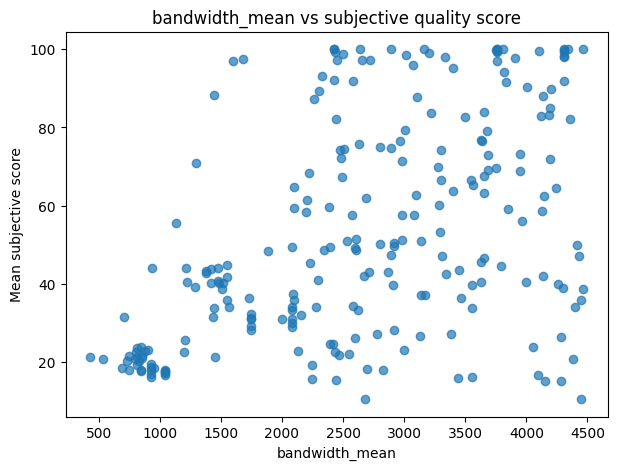

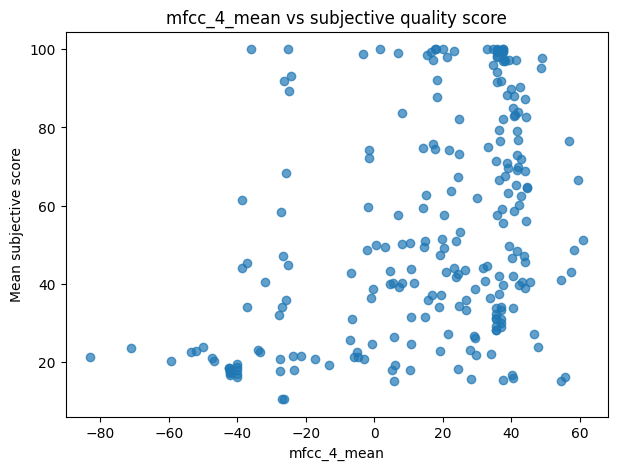

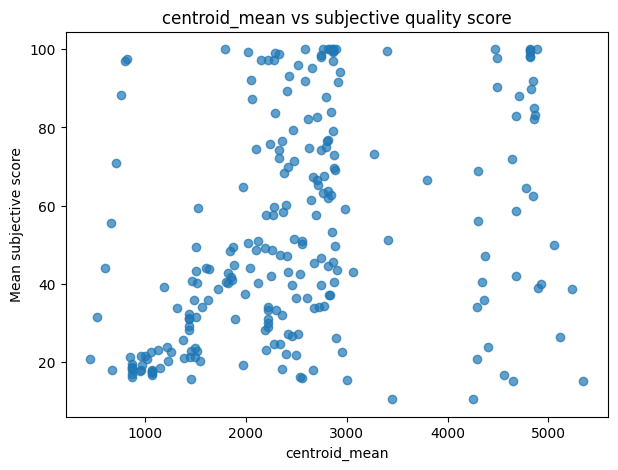

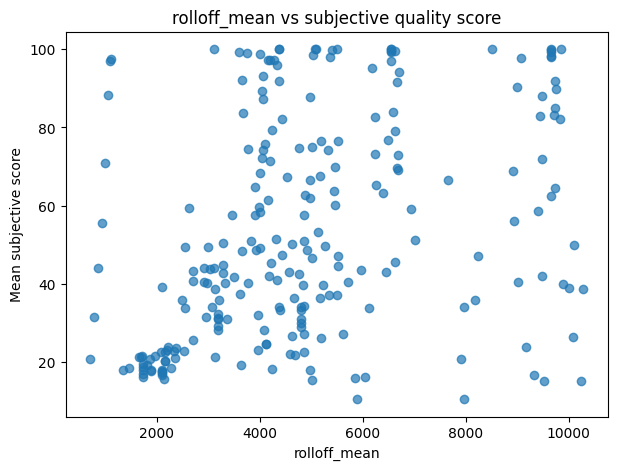

In [25]:
import matplotlib.pyplot as plt

top_features = [
    "bandwidth_mean",
    "mfcc_4_mean",
    "centroid_mean",
    "rolloff_mean"
]

for feature in top_features:

    plt.figure(figsize=(7, 5))

    plt.scatter(
        features_df[feature],
        features_df["score_mean"],
        alpha=0.7
    )

    plt.xlabel(feature)
    plt.ylabel("Mean subjective score")
    plt.title(f"{feature} vs subjective quality score")

    plt.show()